In [2]:
import os
from functools import partial
from typing import Any, Dict, List, Tuple
import math
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# MedCLIP imports (from the repo)
from medclip import MedCLIPModel, MedCLIPVisionModelViT, MedCLIPProcessor

# PEFT (LoRA)
from peft import LoraConfig, get_peft_model

# ---- USER CONFIG ----
MODEL_ID = "kaushalya/medclip"   # or other MedCLIP HF repo; change if needed
DATASET_ID = "itsanmolgupta/mimic-cxr-dataset"
OUTPUT_DIR = "./medclip_finetune_out"
BATCH_SIZE = 16         # per step batch - reduce if OOM
ACCUM_STEPS = 2         # gradient accumulation
NUM_EPOCHS = 50
LR = 8e-5 #8e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_EVERY = 1          # save checkpoint every N epochs
LORA_R = 8
LORA_ALPHA = 32
LORA_DROPOUT = 0.2
TARGET_IMAGE_KEY = "image"   # dataset field that contains image (adjust if different)

WEIGHT_DECAY = 0.05
LR_WARMUP_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 5
MAX_GRAD_NORM = 1.0
TAU_INIT = 0.07 

# ----------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Device:", DEVICE)


Device: cuda


In [3]:
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from medclip import MedCLIPProcessor
import torch

# ------------------------------
# Paths
# ------------------------------
train_df_path = "./tutore_train/train/train_metadata.csv"
train_images_dir = "./tutore_train/train/images_train"

test_df_path = "./tutore_test/test/test_metadata.csv"
test_images_dir = "./tutore_test/test/images_test"

BATCH_SIZE_load = 8
processor = MedCLIPProcessor()

# ------------------------------
# Load CSVs and combine
# ------------------------------
train_df = pd.read_csv(train_df_path)
test_df = pd.read_csv(test_df_path) if os.path.exists(test_df_path) else pd.DataFrame()
full_df = pd.concat([train_df, test_df], ignore_index=True)

# ------------------------------
# Resolve image paths
# ------------------------------
def get_full_path(row):
    train_path = os.path.join(train_images_dir, str(row["image_id"]))
    test_path = os.path.join(test_images_dir, str(row["image_id"]))
    if os.path.exists(train_path):
        return train_path
    elif os.path.exists(test_path):
        return test_path
    return None

full_df["image_path"] = full_df.apply(get_full_path, axis=1)
full_df = full_df.dropna(subset=["image_path"])

# ------------------------------
# TEXT CLEANING (added)
# ------------------------------
# combine text fields
full_df["combined_text"] = (
    full_df["findings"].fillna("").astype(str).str.strip() + " " +
    full_df["impression"].fillna("").astype(str).str.strip()
).str.strip()

# remove empty text
full_df = full_df[full_df["combined_text"].str.len() > 0]

# optional: remove extremely short or useless text
full_df = full_df[full_df["combined_text"].str.len() > 5]

# remove duplicates for cleaner dataset
full_df = full_df.drop_duplicates(subset=["combined_text", "image_path"]).reset_index(drop=True)

print(f"Total usable examples after cleaning: {len(full_df)}")

# ------------------------------
# Dataset class
# ------------------------------
class MedCLIPLocalDataset(Dataset):
    def __init__(self, df, processor, text_col="impression", max_length=256, mode="train"):
        """
        df: pandas DataFrame with text_col and image_path columns
        processor: MedCLIPProcessor
        text_col: "impressions" or "impression"
        max_length: max token length
        mode: "train" or "val"/"test"
        """
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.text_col = text_col
        self.max_length = max_length
        self.mode = mode

        # Augmentations for training
        self.train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
        ])
        # No transforms for validation/test
        self.val_transform = transforms.Compose([])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row[self.text_col] if isinstance(row[self.text_col], str) else ""
        image_path = row["image_path"]

        # Load image
        image = Image.open(image_path).convert("RGB")
        if self.mode == "train":
            image = self.train_transform(image)
        else:
            image = self.val_transform(image)

        # MedCLIP processor handles tokenization
        encoding = self.processor(
            text=text,
            images=image,
            padding=False,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "pixel_values": encoding["pixel_values"][0],
            "input_ids": encoding["input_ids"][0],
            "attention_mask": encoding["attention_mask"][0],
            "raw_text": text,
        }

# --------------------------
# Collate function
# --------------------------
def collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    input_ids = torch.nn.utils.rnn.pad_sequence(
        [b["input_ids"] for b in batch], batch_first=True,
        padding_value=processor.tokenizer.pad_token_id
    )
    attention_mask = torch.nn.utils.rnn.pad_sequence(
        [b["attention_mask"] for b in batch], batch_first=True,
        padding_value=0
    )
    return {
        "pixel_values": pixel_values,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "raw_texts": [b["raw_text"] for b in batch],
    }

# ------------------------------
# Final dataset + split
# ------------------------------
# Split indices
total_len = len(full_df)
train_len = int(0.8 * total_len)
val_len   = int(0.1 * total_len)
test_len  = total_len - train_len - val_len

train_idx, val_idx, test_idx = random_split(range(total_len), [train_len, val_len, test_len])

train_df = full_df.iloc[train_idx.indices]
val_df   = full_df.iloc[val_idx.indices]
test_df  = full_df.iloc[test_idx.indices]

# Dataset objects
ds_train = MedCLIPLocalDataset(train_df, processor=processor, text_col="impression", mode="train")
ds_val   = MedCLIPLocalDataset(val_df,   processor=processor, text_col="impression" , mode="val")
ds_test  = MedCLIPLocalDataset(test_df,  processor=processor, text_col="impression" , mode="val")

# Dataloaders
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE_load, shuffle=True, collate_fn=collate_fn, drop_last=True)
val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE_load, shuffle=False, collate_fn=collate_fn, drop_last=False)
test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE_load, shuffle=False, collate_fn=collate_fn, drop_last=False)


print("✅ Clean dataloaders ready!")
print(f"Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)}")


c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Total usable examples after cleaning: 15731
✅ Clean dataloaders ready!
Train: 12584, Val: 1573, Test: 1574


🚂 Visualizing Train Samples


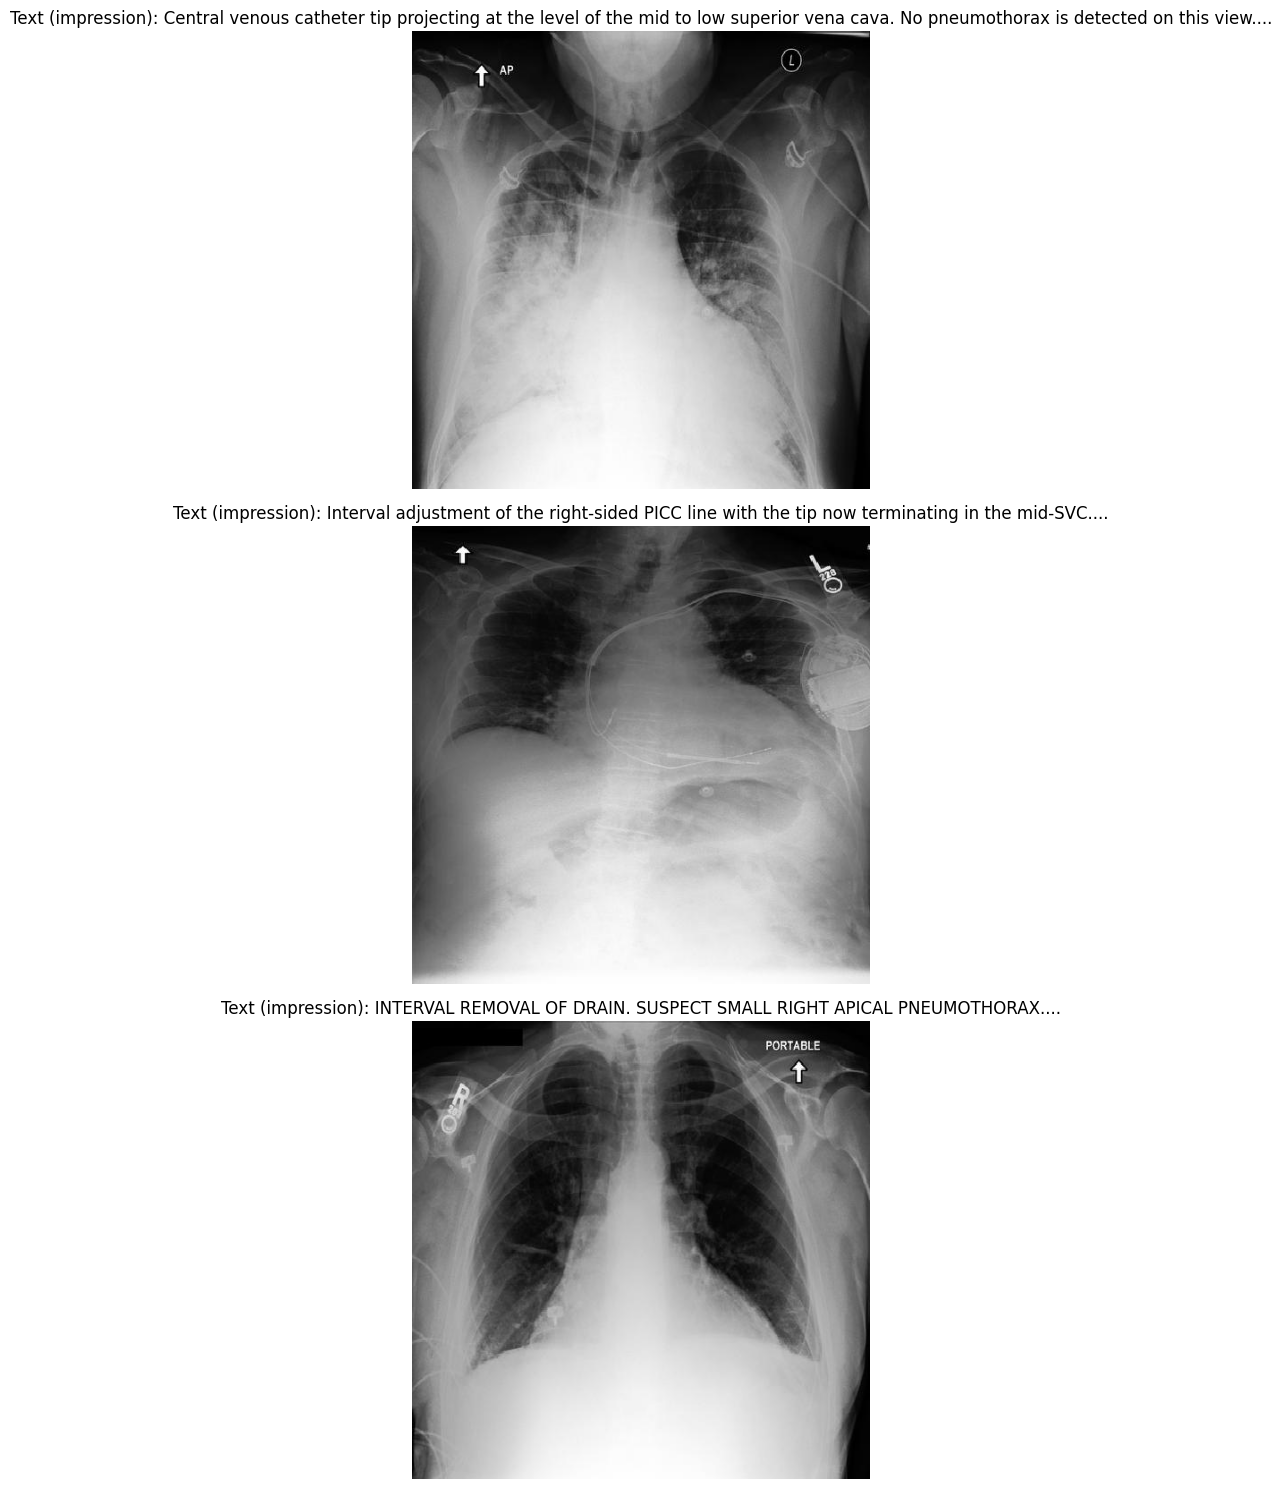

🧪 Visualizing Validation Samples


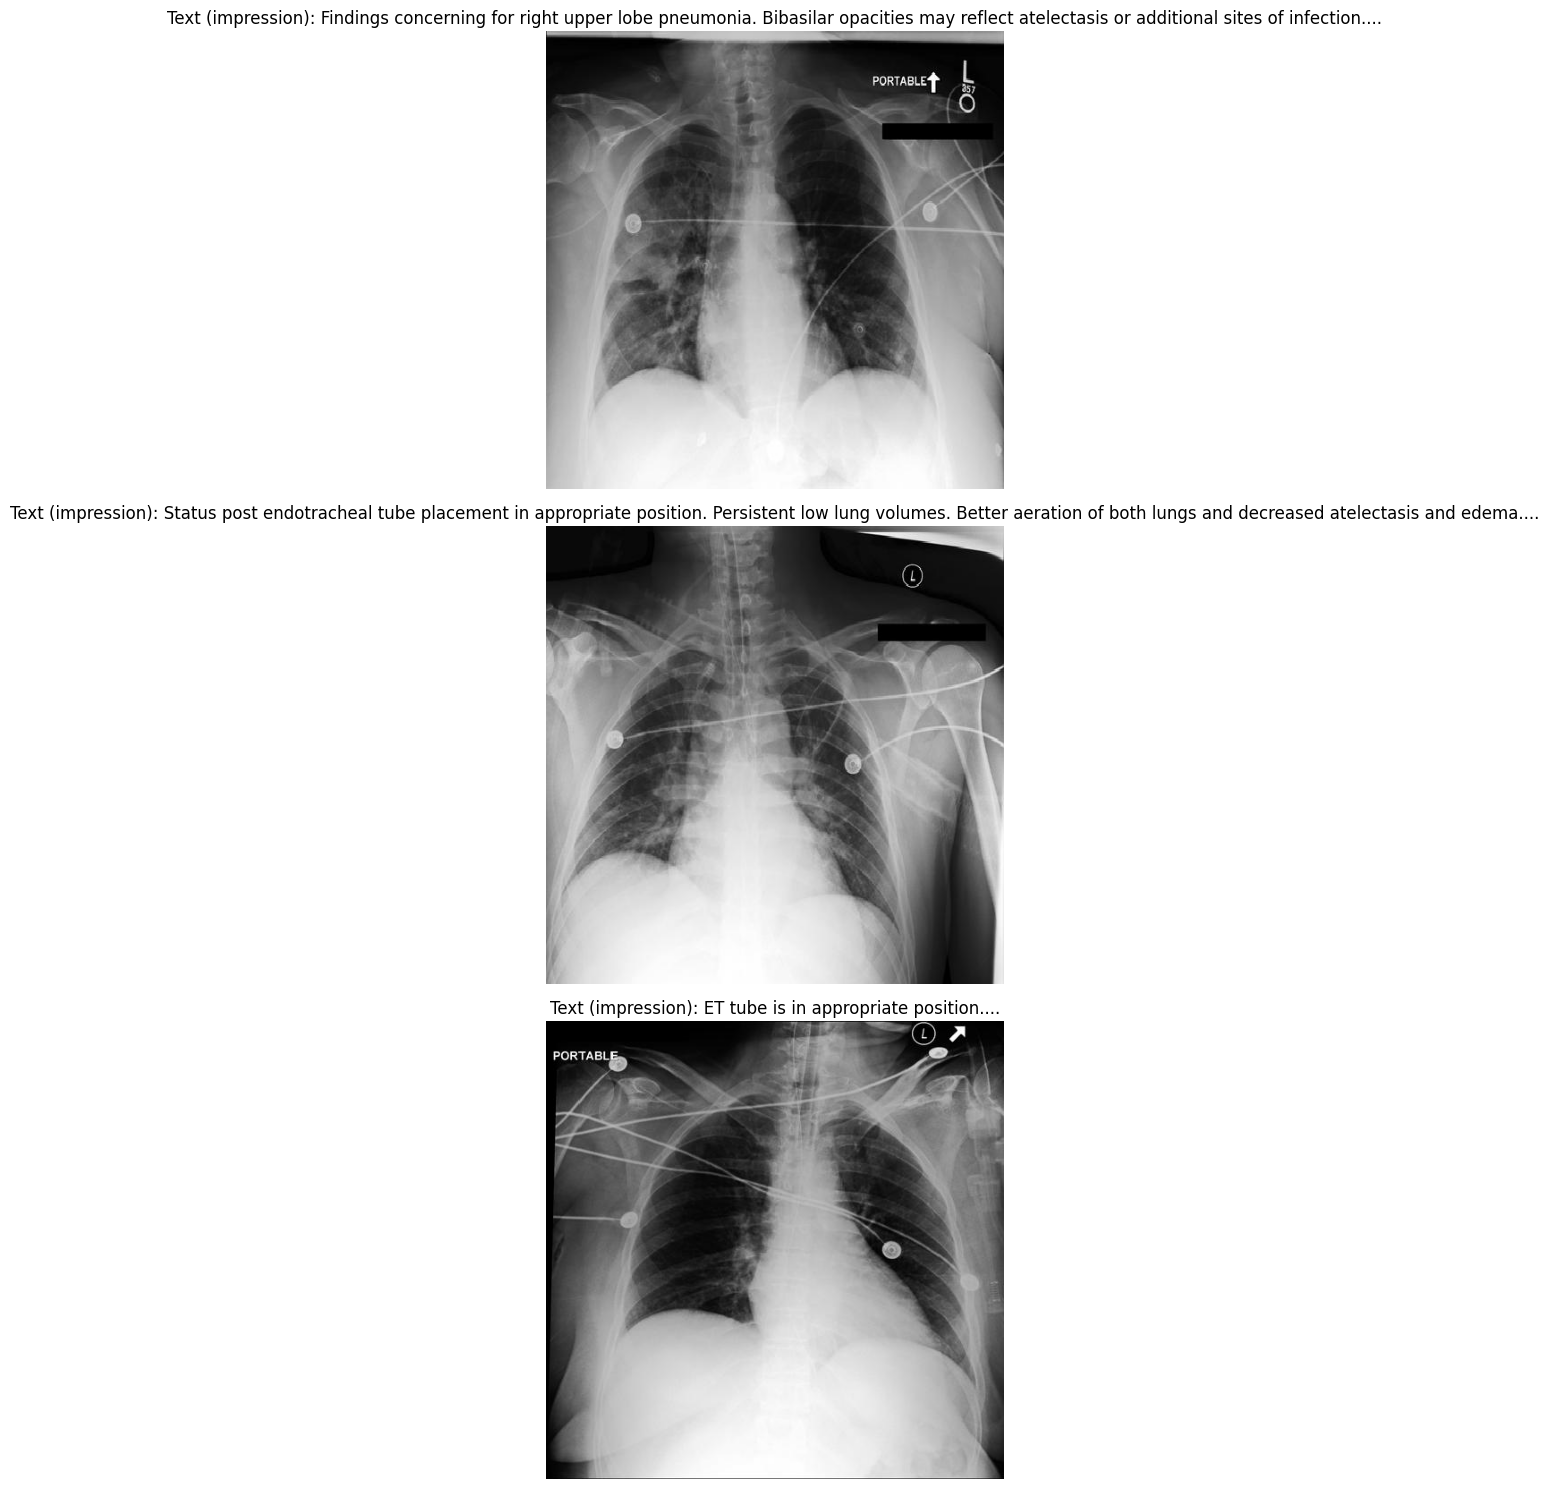

In [4]:
import matplotlib.pyplot as plt
from random import sample

def visualize_samples(df, text_col="impressions", num_samples=5):
    """
    df: DataFrame (train/val/test)
    text_col: "impressions" or "findings"
    num_samples: number of samples to display
    """
    df_samples = df.sample(n=min(num_samples, len(df)))
    
    plt.figure(figsize=(15, 5 * len(df_samples)))
    
    for i, (_, row) in enumerate(df_samples.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        text = row[text_col]
        
        plt.subplot(len(df_samples), 1, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Text ({text_col}): {text[:200]}...", fontsize=12)  # show first 200 chars
    plt.tight_layout()
    plt.show()

# Example usage:
print("🚂 Visualizing Train Samples")
visualize_samples(train_df, text_col="impression", num_samples=3)

print("🧪 Visualizing Validation Samples")
visualize_samples(val_df, text_col="impression", num_samples=3)


In [5]:
def get_module_device(module: nn.Module) -> torch.device:
    return next(module.parameters()).device

def freeze_params(module: nn.Module, freeze_top_percent: float = 1.0) -> None:
    """
    Freeze top percentage (starting from first parameter) of module parameters.
    freeze_top_percent=1.0 -> freeze ALL parameters
    freeze_top_percent=0.7 -> freeze first 70% of parameters, leaving last 30% trainable
    """
    all_params = list(module.parameters())
    n = len(all_params)
    freeze_n = int(math.floor(n * freeze_top_percent))
    for i, p in enumerate(all_params):
        p.requires_grad = False if i < freeze_n else True

def print_trainable_parameters(model: nn.Module) -> None:
    trainable, total = 0, 0
    for _, p in model.named_parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()
    print(f"Trainable params: {trainable/1e6:.4f}M / {total/1e6:.4f}M ({100*trainable/total:.2f}%)")

def list_trainable_modules(model: nn.Module, prefix=""):
    for name, module in model.named_modules():
        # show modules that contain parameters
        if any(p.requires_grad for p in module.parameters(recurse=False)):
            print(name)


In [6]:
# load MedCLIP model (vision_cls optional)
model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
# from_pretrained() in medclip repo usually expects to fetch weights; handle exceptions
try:
    model.from_pretrained(MODEL_ID)
except Exception as e:
    print("Warning: model.from_pretrained failed with:", e)
    # try a fallback if necessary (user can change MODEL_ID)
model.to(DEVICE)
print("Model loaded. Device:", get_module_device(model))

c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at microsoft/swin-tiny-patch4-window7-224 were not used when initializing SwinModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing SwinModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing SwinModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\t

load model weight from: kaushalya/medclip
Model loaded. Device: cuda:0


## testing model


In [2]:
from medclip import MedCLIPModel, MedCLIPVisionModelViT
from medclip import MedCLIPProcessor
from PIL import Image

# prepare for the demo image and texts
processor = MedCLIPProcessor()
image = Image.open('./tutore_test/test/images_test/img_10001.png')
inputs = processor(
    text=["Retrocardiac opacity is poorly seen on this single view but could reflect atelectasis or developing infectious process. Lungs are somewhat low in volume giving the appearance of vascular crowding, though mild pulmonary vascular congestion is present as well. Mild right base atelectasis is noted, early infection not excluded in the appropriate clinical setting. Cardiac size is moderately enlarged with changes of prior coronary bypass graft noted. No pneumothorax or pleural effusion is seen. ", 
        "A single AP radiograph of the chest was obtained. As before, the patient is status post midline sternotomy and CABG. Lung volumes are slightly low. There is crowding of the bronchovascular structures, but no pulmonary edema is present. New heterogeneous opacities at the left lung base are some combination of atelectasis, and small effusion, though infection is not excluded. The lungs are otherwise clear. There is no pneumothorax. Left sided rib deformities appear chronic. Left PICC has been removed. ",
        "There is moderate cardiomegaly. There is pulmonary vascular redistribution with hazy ill-defined vascularity. There is volume loss at the bases. Right IJ line is unchanged. There small bilateral pleural effusions. "], 
    images=image, 
    return_tensors="pt", 
    padding=True
    )

# pass to MedCLIP model
model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
model.from_pretrained()
model.cuda()
outputs = model(**inputs)
logits = outputs['logits_per_text']
probs = torch.softmax(logits, dim=0)  # dim=0 car logits_per_text est (n_texts, 1)
for i, txt in enumerate(["1: true", "2: false", "3: false"]):
    print(f"{txt:30s} -> logit: {logits[i].item():.3f} | prob: {probs[i].item()*100:.1f}%")

c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (123 > 77). Running this sequence through the model will result in indexing errors
c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Some weights of the model checkpoint at microsoft/swin-tiny-patch4-window7-224 were not used when initi

load model weight from: ./pretrained/medclip-vit
1: true                        -> logit: 0.136 | prob: 33.5%
2: false                       -> logit: 0.128 | prob: 33.2%
3: false                       -> logit: 0.134 | prob: 33.4%


## training loop

In [6]:
from torch.cuda.amp import autocast, GradScaler
from typing import Optional
from torch.cuda.amp import autocast, GradScaler

def freeze_layernorm(model: nn.Module):
    """Freeze LayerNorm modules (eval + disable grads)."""
    for module in model.modules():
        if isinstance(module, (nn.LayerNorm,)):
            module.eval()
            for p in module.parameters():
                p.requires_grad = False

def extract_logits(outputs, tau: float = TAU_INIT) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Robust extractor: supports dict outputs OR ModelOutput objects (attributes).
    Returns (logits_per_image, logits_per_text) — both are tensors.
    """
    def _get(o, *names):
        # try dict first, then attribute access
        if isinstance(o, dict):
            for n in names:
                if n in o and o[n] is not None:
                    return o[n]
        else:
            for n in names:
                v = getattr(o, n, None)
                if v is not None:
                    return v
        return None

    # 1) Try direct logits keys
    lpi = _get(outputs, "logits_per_image", "logits_image", "logits")
    lpt = _get(outputs, "logits_per_text", "logits_text")

    if lpi is not None:
        # if only 'logits' provided (square matrix), mirror for text
        if lpt is None:
            lpt = lpi.t()
        return lpi, lpt

    # 2) Try embeddings (many possible key names)
    img_emb = _get(outputs,
                   "image_embeds", "image_embed", "img_embeds", "img_embed",
                   "image_emb", "img_emb")
    txt_emb = _get(outputs,
                   "text_embeds", "text_embed", "txt_embeds", "txt_embed",
                   "text_emb", "txt_emb")

    if img_emb is not None and txt_emb is not None:
        # normalize then compute logits = cosine / tau
        img_emb = img_emb / (img_emb.norm(dim=-1, keepdim=True) + 1e-12)
        txt_emb = txt_emb / (txt_emb.norm(dim=-1, keepdim=True) + 1e-12)
        logits_per_image = (img_emb @ txt_emb.t()) / tau
        logits_per_text = logits_per_image.t()
        return logits_per_image, logits_per_text

    # Nothing found — raise helpful error
    # Try to produce a short diagnostic
    try:
        out_keys = list(outputs.keys()) if isinstance(outputs, dict) else [a for a in dir(outputs) if not a.startswith("_")]
    except Exception:
        out_keys = str(type(outputs))
    raise RuntimeError(
        "extract_logits: could not find logits or embeddings in model outputs. "
        "Output type: %s. Available keys/attrs (truncated): %s" % (type(outputs), str(out_keys)[:300])
    )


def compute_contrastive_loss(logits_per_image: torch.Tensor, logits_per_text: torch.Tensor) -> torch.Tensor:
    """
    Symmetric cross entropy (InfoNCE style) between images and text.
    logits are expected to be already scaled by 1/tau.
    """
    device = logits_per_image.device
    targets = torch.arange(logits_per_image.size(0), device=device)
    loss_img = nn.CrossEntropyLoss()(logits_per_image, targets)
    loss_txt = nn.CrossEntropyLoss()(logits_per_text, targets)
    return (loss_img + loss_txt) / 2.0

def compute_per_sample_loss(logits_per_image: torch.Tensor, logits_per_text: torch.Tensor) -> torch.Tensor:
    """
    Returns per-sample symmetric loss: (CE_row + CE_col) / 2
    Useful to detect noisy pairs.
    """
    device = logits_per_image.device
    targets = torch.arange(logits_per_image.size(0), device=device)
    ce = nn.CrossEntropyLoss(reduction="none")
    loss_img = ce(logits_per_image, targets)       # shape (B,)
    loss_txt = ce(logits_per_text, targets)       # shape (B,)
    return 0.5 * (loss_img + loss_txt)

def compute_recall_at_k(model, dataloader, k=1, tau=1.0):
    model.eval()
    all_img_embs, all_txt_embs = [], []

    with torch.no_grad():
        for batch in dataloader:
            out = model(
                pixel_values=batch["pixel_values"].to(DEVICE),
                input_ids=batch["input_ids"].to(DEVICE),
                attention_mask=batch["attention_mask"].to(DEVICE)
            )

            img = out["img_embeds"]          # shape [B, D]
            txt = out["text_embeds"]         # shape [B, D]

            all_img_embs.append(img)
            all_txt_embs.append(txt)

    # ------------- FIX: concatenate embeddings, not logits -------------
    img_embs = torch.cat(all_img_embs, dim=0)  # [N, D]
    txt_embs = torch.cat(all_txt_embs, dim=0)  # [N, D]
    # -------------------------------------------------------------------

    # Compute similarity
    sims = (img_embs @ txt_embs.t()) * tau     # [N, N]

    # Ranking
    ranks = sims.argsort(dim=1, descending=True)
    targets = torch.arange(len(img_embs)).to(DEVICE)

    # Compute metrics
    recall = (ranks[:, :k] == targets.unsqueeze(1)).any(dim=1).float().mean().item()
    return recall


def find_noisy_samples(dataloader: DataLoader, model, tau: float = TAU_INIT, threshold: float = 3.0):
    """
    Scan validation set and return examples with unusually high per-sample loss.
    threshold: z-score threshold on per-sample loss or absolute threshold.
    """
    model.eval()
    per_sample_losses = []
    meta = []  # store (raw_text, image_path) per example if available
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Find noisy"):
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)

            outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
            lpi, lpt = extract_logits(outputs, tau=tau)
            loss_per_sample = compute_per_sample_loss(lpi, lpt)  # shape (B,)
            per_sample_losses.append(loss_per_sample.cpu())
            meta.extend(batch.get("raw_texts", [""] * pixel_values.size(0)))

    all_losses = torch.cat(per_sample_losses, dim=0)
    mean = all_losses.mean().item()
    std = all_losses.std().item()
    # mark high-loss items
    idxs = torch.where(all_losses > mean + threshold * (std + 1e-9))[0].tolist()
    noisy = [{"idx": int(i), "loss": float(all_losses[i].item()), "text": meta[i]} for i in idxs]
    return {"mean": mean, "std": std, "noisy": noisy}

# -------------------------
# evaluate loss function (use extract_logits)
# -------------------------
def evaluate_model_loss(model: nn.Module, loader: DataLoader, tau: float = TAU_INIT) -> float:
    model.eval()
    running, n = 0.0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)

            outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
            lpi, lpt = extract_logits(outputs, tau=tau)
            loss = compute_contrastive_loss(lpi, lpt)
            bsz = pixel_values.size(0)
            running += loss.item() * bsz
            n += bsz
    return running / max(1, n)

# -------------------------
# Training loop (Approach A implemented)
# -------------------------
def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
                mode: str = "lora",
                num_epochs: int = NUM_EPOCHS, lr: float = LR,
                accumulation_steps: int = ACCUM_STEPS, save_dir: str = OUTPUT_DIR,
                resume_from: str = None,
                weight_decay: float = WEIGHT_DECAY,
                lr_warmup_epochs: int = LR_WARMUP_EPOCHS,
                early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
                max_grad_norm: float = MAX_GRAD_NORM,
                tau_init: float = TAU_INIT):
    # Ensure directory
    os.makedirs(save_dir, exist_ok=True)

    # Freeze layernorms BEFORE moving to device
    freeze_layernorm(model)
    model = model.to(DEVICE)

    # optimizer
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)

    # scheduler
    steps_per_epoch = math.ceil(len(train_loader) / accumulation_steps)
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = max(1, steps_per_epoch * lr_warmup_epochs)
    scheduler = None
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    scaler = torch.cuda.amp.GradScaler() if DEVICE.startswith("cuda") else None
    use_amp = scaler is not None
    global_step = 0

    # resume logic (simple)
    if resume_from is not None:
        if mode == "lora":
            model.load_pretrained(resume_from)
        else:
            ckpt = torch.load(resume_from, map_location=DEVICE)
            model.load_state_dict(ckpt)

    train_history, val_history = [], []
    recall1_history, recall5_history, recall10_history = [], [], []
    best_recall1 = -1.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        seen = 0
        optimizer.zero_grad()
        pbar = tqdm(train_loader, desc=f"Train epoch {epoch+1}/{num_epochs}", leave=False)

        for step, batch in enumerate(pbar):
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            bsz = pixel_values.size(0)

            if use_amp:
                with torch.cuda.amp.autocast():
                    outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
                    lpi, lpt = extract_logits(outputs, tau=tau_init)
                    loss = compute_contrastive_loss(lpi, lpt)
                    loss = loss / accumulation_steps
                scaler.scale(loss).backward()
            else:
                outputs = model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
                lpi, lpt = extract_logits(outputs, tau=tau_init)
                loss = compute_contrastive_loss(lpi, lpt)
                loss = loss / accumulation_steps
                loss.backward()

            # update step
            if (step + 1) % accumulation_steps == 0:
                if use_amp:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_grad_norm)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), max_grad_norm)
                    optimizer.step()
                optimizer.zero_grad()
                global_step += 1
                if scheduler is not None:
                    scheduler.step()

            # accumulate running loss (per-example sum)
            running_loss += loss.item() * accumulation_steps * bsz
            seen += bsz
            pbar.set_postfix(train_loss=f"{(running_loss/seen):.4f}")

        epoch_train_loss = running_loss / max(1, seen)
        train_history.append(epoch_train_loss)

        # Validation: compute val_loss and recall@1/@5/@10
        val_loss = evaluate_model_loss(model, val_loader, tau=tau_init)
        r1 = compute_recall_at_k(model, val_loader, k=1, tau=tau_init)
        r5 = compute_recall_at_k(model, val_loader, k=5, tau=tau_init)
        r10 = compute_recall_at_k(model, val_loader, k=10, tau=tau_init)

        val_history.append(val_loss)
        recall1_history.append(r1)
        recall5_history.append(r5)
        recall10_history.append(r10)

        print(f"Epoch {epoch+1} | train_loss: {epoch_train_loss:.4f} | val_loss: {val_loss:.4f} | R@1:{r1:.4f} R@5:{r5:.4f} R@10:{r10:.4f}")

        # Save csv history
        # Save csv history (now includes R@1, R@5, R@10)
        csv_path = os.path.join(save_dir, "loss_history.csv")
        with open(csv_path, "w") as f:
            f.write("epoch,train_loss,val_loss,recall1,recall5,recall10\n")
            for ep in range(1, len(train_history) + 1):
                f.write(
                    f"{ep},"
                    f"{train_history[ep-1]:.6f},"
                    f"{val_history[ep-1]:.6f},"
                    f"{recall1_history[ep-1]:.6f},"
                    f"{recall5_history[ep-1]:.6f},"
                    f"{recall10_history[ep-1]:.6f}\n"
                )


        # Save best Recall@1 (no early stopping)
        if r1 > best_recall1:
            best_recall1 = r1
            if mode == "lora":
                peft_dir = os.path.join(save_dir, f"{mode}_best")
                model.save_pretrained(peft_dir)
                print("💾 Saved best LoRA adapters to", peft_dir)
            else:
                ckpt_path = os.path.join(save_dir, f"{mode}_best.pt")
                torch.save(model.state_dict(), ckpt_path)
                print("💾 Saved best model state to", ckpt_path)

        # Save LoRA adapters every 5 epochs
        if mode == "lora" and (epoch + 1) % 5 == 0:
            save_path = os.path.join(save_dir, f"epoch_{epoch+1}_lora")
            model.save_pretrained(save_path)
            print(f"📁 Saved periodic checkpoint at: {save_path}")


    return {
        "train_history": train_history,
        "val_history": val_history,
        "recall1_history": recall1_history,
        "best_recall1": best_recall1
    }


## Fine-tuning last 30 layers

In [ ]:
model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
model.from_pretrained(MODEL_ID)
model.to(DEVICE)

# Freeze everything
for p in model.parameters():
    p.requires_grad = False

# Helper
def unfreeze_last_fraction(module, fraction=0.3):
    layers = list(module.modules())
    cutoff = int(len(layers) * (1 - fraction))
    for l in layers[cutoff:]:
        for p in l.parameters(recurse=False):
            p.requires_grad = True

unfreeze_last_fraction(model.vision_model, 0.3)

print_trainable_parameters(model)

train_model(
    model,
    train_loader,
    val_loader,
    mode="last30",
    num_epochs=NUM_EPOCHS,     
    lr=LR,
    accumulation_steps=ACCUM_STEPS,
    save_dir=OUTPUT_DIR,
)


In [ ]:
def evaluate_model(model, val_loader, device="cuda"):
    model.eval()
    total_loss = 0
    total_samples = 0
    correct_i2t = 0
    correct_t2i = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # -----------------------------
            #   1) Extract logits safely
            # -----------------------------
            logits_i = None
            logits_t = None

            if "logits" in outputs and outputs["logits"] is not None:
                logits_i = outputs["logits"]

            if logits_i is None and "logits_per_image" in outputs:
                logits_i = outputs["logits_per_image"]

            if "logits_per_text" in outputs:
                logits_t = outputs["logits_per_text"]

            # -----------------------------
            # 2) If no logits → fallback to embeddings
            # -----------------------------
            if logits_i is None or logits_t is None:
                img_emb = (
                    outputs.get("img_embeds")
                    or outputs.get("image_embeds")
                    or outputs.get("vision_embeddings")
                )
                txt_emb = (
                    outputs.get("text_embeds")
                    or outputs.get("text_embeddings")
                )

                if img_emb is None or txt_emb is None:
                    raise RuntimeError(f"Could not find logits or embeddings in outputs: {outputs.keys()}")

                # normalize
                img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
                txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)

                logits_i = img_emb @ txt_emb.t()
                logits_t = logits_i.t()

            # -----------------------------
            #  3) Compute contrastive loss
            # -----------------------------
            loss = compute_contrastive_loss(logits_i, logits_t)
            total_loss += loss.item() * pixel_values.size(0)
            total_samples += pixel_values.size(0)

            # -----------------------------
            # 4) Compute ranking accuracy
            # -----------------------------
            targets = torch.arange(pixel_values.size(0)).to(device)

            pred_i2t = logits_i.argmax(dim=1)
            pred_t2i = logits_t.argmax(dim=1)

            correct_i2t += (pred_i2t == targets).sum().item()
            correct_t2i += (pred_t2i == targets).sum().item()

    return {
        "val_loss": total_loss / total_samples,
        "image_to_text_acc": correct_i2t / total_samples,
        "text_to_image_acc": correct_t2i / total_samples,
    }


In [ ]:
model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
model.from_pretrained(MODEL_ID)

# Load fine-tuned weights
ckpt_path = r"C:\Users\ahmed\OneDrive\Desktop\tutore\medclip_finetune_out\last30_epoch26.pt"
state_dict = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(state_dict, strict=False)

model.to(DEVICE)
model.eval()

metrics = evaluate_model(model, val_loader, device=DEVICE)
print(metrics)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def evaluate_clip_recall(model, dataloader, device="cuda", topk=(1, 5, 10)):
    model.eval()
    all_img_embeds = []
    all_text_embeds = []

    # Collect embeddings
    for batch in dataloader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(pixel_values=pixel_values,
                        input_ids=input_ids,
                        attention_mask=attention_mask)

        all_img_embeds.append(outputs["img_embeds"].cpu())
        all_text_embeds.append(outputs["text_embeds"].cpu())

    all_img_embeds = torch.cat(all_img_embeds)
    all_text_embeds = torch.cat(all_text_embeds)

    # Normalize embeddings
    all_img_embeds = all_img_embeds / all_img_embeds.norm(dim=-1, keepdim=True)
    all_text_embeds = all_text_embeds / all_text_embeds.norm(dim=-1, keepdim=True)

    # Compute cosine similarity
    sims = all_text_embeds @ all_img_embeds.t()  # (N_text, N_img)

    recalls = {}
    for k in topk:
        correct = 0
        for i in range(sims.size(0)):
            topk_indices = sims[i].topk(k).indices
            if i in topk_indices:
                correct += 1
        recalls[f"R@{k}"] = correct / sims.size(0)

    print("Recall metrics:", recalls)

    # Confusion-like heatmap for top-1 matches
    # preds = sims.argmax(dim=1).numpy()
    # true = np.arange(len(dataloader.dataset))
    # cm = confusion_matrix(true, preds)
    # disp = ConfusionMatrixDisplay(cm)
    # fig, ax = plt.subplots(figsize=(10,10))
    # disp.plot(ax=ax)
    # plt.title("Top-1 Retrieval Confusion Matrix")
    # plt.show()

    return recalls


In [ ]:
import torch
import os
import json

CHECKPOINT_DIR = r"C:\Users\ahmed\OneDrive\Desktop\tutore\medclip_finetune_out"
RESULTS_FILE = "training_metrics.json"

all_metrics = []

for epoch in range(1, 28):  # 1 to 27
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"last30_epoch{epoch}.pt")
    if not os.path.exists(ckpt_path):
        continue
    
    print(f"Evaluating checkpoint: epoch {epoch}")

    # load model weights
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state)

    # evaluate
    val_loss = evaluate_model_loss(model, val_loader)
    recalls = evaluate_clip_recall(model, test_loader, device=DEVICE, topk=(1,5,10))

    # store
    all_metrics.append({
        "epoch": epoch,
        "val_loss": val_loss,
        "R1": recalls["R@1"],
        "R5": recalls["R@5"],
        "R10": recalls["R@10"]
    })

# save
with open(RESULTS_FILE, "w") as f:
    json.dump(all_metrics, f, indent=4)

print("Saved metrics →", RESULTS_FILE)


In [ ]:
import matplotlib.pyplot as plt

metrics = all_metrics

epochs = [m["epoch"] for m in metrics]
losses = [m["val_loss"] for m in metrics]
R1 = [m["R1"] for m in metrics]
R5 = [m["R5"] for m in metrics]
R10 = [m["R10"] for m in metrics]

plt.figure(figsize=(12,5))

# ----- Loss -----
plt.subplot(1,2,1)
plt.plot(epochs, losses)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ----- Recall -----
plt.subplot(1,2,2)
plt.plot(epochs, R1, label="R@1")
plt.plot(epochs, R5, label="R@5")
plt.plot(epochs, R10, label="R@10")
plt.title("Recall over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.show()


In [ ]:
subset_indices = np.random.choice(len(test_loader.dataset), size=20, replace=False)
subset_dataset = torch.utils.data.Subset(test_loader.dataset, subset_indices)
subset_loader = torch.utils.data.DataLoader(subset_dataset, batch_size=16, shuffle=False , collate_fn=collate_fn)


recalls = evaluate_clip_recall(model, subset_loader, device=DEVICE, topk=(1,5,10))


## Fine-tuning image encoder (freezing text encoder)

## LoRA

In [ ]:
model.eval()
batch = next(iter(val_loader))

with torch.no_grad():
    out = model(
        pixel_values=batch["pixel_values"].cuda(),
        input_ids=batch["input_ids"].cuda(),
        attention_mask=batch["attention_mask"].cuda()
    )

print("Keys returned by model:", out.keys())
for k, v in out.items():
    try:
        print(f"{k}: {v.shape}")
    except:
        print(f"{k}: NOT a tensor")


In [7]:
from peft import LoraConfig, get_peft_model

model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
model.from_pretrained(MODEL_ID)
model.to(DEVICE)

for p in model.parameters():
    p.requires_grad = False

lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["query", "key", "value"],
    bias="none",
    task_type="FEATURE_EXTRACTION"
)

model = get_peft_model(model, lora_cfg)

print_trainable_parameters(model)

train_model(
    model,
    train_loader,
    val_loader,
    mode="lora",
    num_epochs=NUM_EPOCHS,
    lr=LR,
    accumulation_steps=ACCUM_STEPS,
    save_dir=OUTPUT_DIR
)


Some weights of the model checkpoint at microsoft/swin-tiny-patch4-window7-224 were not used when initializing SwinModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing SwinModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing SwinModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.trans

load model weight from: kaushalya/medclip
Trainable params: 0.6543M / 137.2704M (0.48%)


C:\Users\ahmed\AppData\Local\Temp\ipykernel_34008\2434352064.py:205: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE.startswith("cuda") else None


Train epoch 1/50:   0%|          | 0/1573 [00:00<?, ?it/s]

C:\Users\ahmed\AppData\Local\Temp\ipykernel_34008\2434352064.py:235: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Train epoch 49/50:   0%|          | 0/1573 [00:00<?, ?it/s]

Validation:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch 49 | train_loss: 0.8107 | val_loss: 1.0367 | R@1:0.0184 R@5:0.0693 R@10:0.1240


Train epoch 50/50:   0%|          | 0/1573 [00:00<?, ?it/s]

KeyboardInterrupt: 

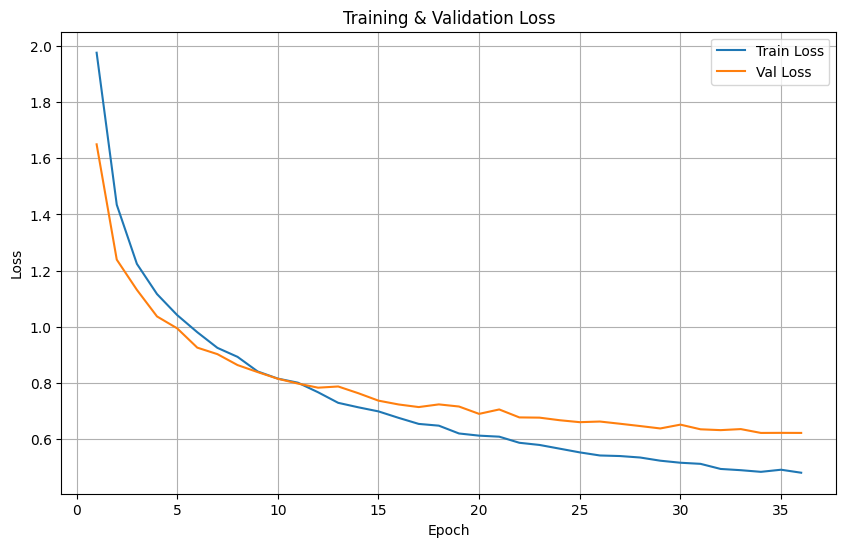

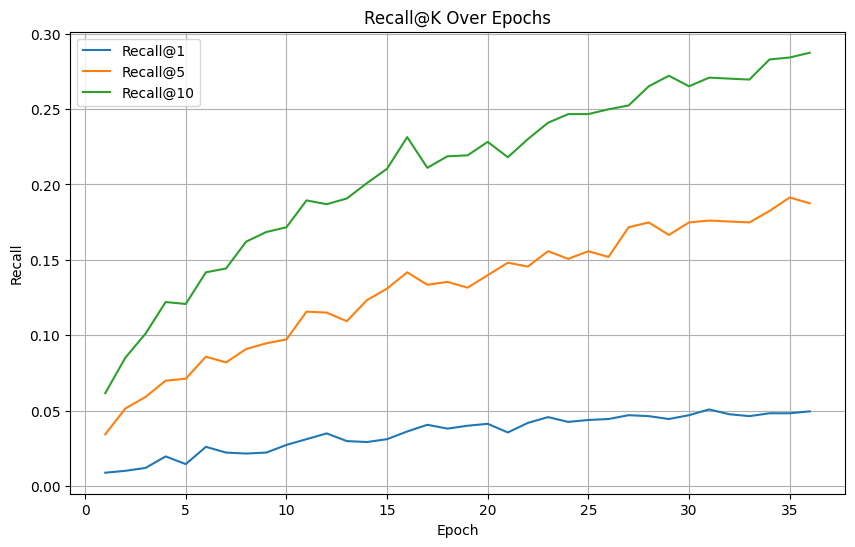

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./lora_findings/loss_history.csv")

plt.figure(figsize=(10, 6))
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df["epoch"], df["recall1"], label="Recall@1")
plt.plot(df["epoch"], df["recall5"], label="Recall@5")
plt.plot(df["epoch"], df["recall10"], label="Recall@10")

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Recall@K Over Epochs")
plt.legend()
plt.grid()
plt.show()


## testing fine-tuned model

In [7]:
from medclip import MedCLIPModel, MedCLIPVisionModelViT
from peft import PeftModel
import torch

# 1️⃣ Charger le modèle MedCLIP "base"
base_model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
base_model.from_pretrained()
base_model.cuda()

# 2️⃣ Charger les LoRA adapters (finetuned)
lora_path = "./lora_findings/lora"   # 👉 mets ton dossier ici

model = PeftModel.from_pretrained(base_model, lora_path)
model.eval()
print("✅ Finetuned LoRA model loaded!")


Some weights of the model checkpoint at microsoft/swin-tiny-patch4-window7-224 were not used when initializing SwinModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing SwinModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing SwinModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing BertModel: ['cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transfo

load model weight from: ./pretrained/medclip-vit
✅ Finetuned LoRA model loaded!


c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\peft\utils\save_and_load.py:198: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  adapters_weights = torch

In [1]:
import torch
from PIL import Image
from medclip import MedCLIPModel, MedCLIPVisionModelViT, MedCLIPProcessor
from peft import PeftModel

# -----------------------------
# 1) Load processor + image + texts
# -----------------------------
processor = MedCLIPProcessor()
image = Image.open('./tutore_test/test/images_test/img_3638.png')
inputs = processor(
    text=["Normal cardiomediastinal and hilar contours. Normal pleural surfaces. Fully expanded, clear lungs without evidence of acute pneumonia or pulmonary vascular congestion.  ", 
        "There is moderate to severe interstitial edema. The cardiac silhouette is normal. There are bilateral small pleural effusions. There is no pneumothorax. Calcifications of the aortic arch are noted.  ",
        "There is moderate cardiomegaly. There is pulmonary vascular redistribution with hazy ill-defined vascularity. There is volume loss at the bases. Right IJ line is unchanged. There small bilateral pleural effusions. "], 
    images=image, 
    return_tensors="pt", 
    padding=True
    )
inputs = {k: v.cuda() for k, v in inputs.items()}

# -----------------------------
# 2) Load base MedCLIP (NOT finetuned)
# -----------------------------
base_model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
base_model.from_pretrained()
base_model.cuda()
base_model.eval()

with torch.no_grad():
    base_out = base_model(**inputs)
    base_logits = base_out["logits_per_text"]
    base_probs = torch.softmax(base_logits, dim=0)

# -----------------------------
# 3) Load Finetuned MedCLIP + LoRA adapters
# -----------------------------
lora_path = "./medclip_finetune_out/lora_best" 

ft_model = MedCLIPModel(vision_cls=MedCLIPVisionModelViT)
ft_model.from_pretrained()
ft_model = PeftModel.from_pretrained(ft_model, lora_path)
ft_model.cuda()
ft_model.eval()

with torch.no_grad():
    ft_out = ft_model(**inputs)
    ft_logits = ft_out["logits_per_text"]
    ft_probs = torch.softmax(ft_logits, dim=0)

# -----------------------------
# 4) Display side-by-side comparison
# -----------------------------
print("\n========================")
print("🔍 COMPARISON: BASE vs FINETUNED")
print("========================\n")

texts = ["text 1 (true)" , "text 2" , "text 3"]

for i, txt in enumerate(texts):
    print(f"TEXT {i+1}: {txt[:50]} : logit={base_logits[i].item():.3f} | prob={base_probs[i].item()*100:.1f}%")

print("-" * 70)

for i, txt in enumerate(texts):
    print(f"TEXT {i+1}: {txt[:50]} : logit={ft_logits[i].item():.3f} | prob={ft_probs[i].item()*100:.1f}%")


c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Some weights of the model checkpoint at microsoft/swin-tiny-patch4-window7-224 were not used when initializing SwinModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing SwinModel from the checkpoint of a model trained on another task or with anoth

load model weight from: ./pretrained/medclip-vit


Some weights of the model checkpoint at microsoft/swin-tiny-patch4-window7-224 were not used when initializing SwinModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing SwinModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing SwinModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.predictions.tra

load model weight from: ./pretrained/medclip-vit

🔍 COMPARISON: BASE vs FINETUNED

TEXT 1: text 1 (true) : logit=0.525 | prob=33.4%
TEXT 2: text 2 : logit=0.524 | prob=33.4%
TEXT 3: text 3 : logit=0.520 | prob=33.2%
----------------------------------------------------------------------
TEXT 1: text 1 (true) : logit=5.137 | prob=100.0%
TEXT 2: text 2 : logit=-2.859 | prob=0.0%
TEXT 3: text 3 : logit=-3.742 | prob=0.0%


c:\Users\ahmed\OneDrive\Desktop\tutore\.tutore_venv\Lib\site-packages\peft\utils\save_and_load.py:198: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  adapters_weights = torch

In [12]:
import torch
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tqdm import tqdm

def evaluate_models(base_model, ft_model, processor,
                    csv_path="./tutore_test/test/test_metadata.csv",
                    img_dir="./tutore_test/test/images_test"):
    """
    Evaluates MedCLIP before and after finetuning.
    Computes:
        - Recall@1, Recall@5, Recall@10
        - Accuracy, Precision, Recall, F1
        - Plots comparing metrics
    """

    df = pd.read_csv(csv_path)

    base_correct_top1 = 0
    base_correct_top5 = 0
    base_correct_top10 = 0

    ft_correct_top1 = 0
    ft_correct_top5 = 0
    ft_correct_top10 = 0

    base_preds = []
    ft_preds = []
    y_true = []

    print("\n🔍 Evaluating on Test Set...\n")

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        image_id = row["image_id"]
        true_text = row["findings"]  # ground truth report

        # Load image
        img_path = f"{img_dir}/{image_id}"
        image = Image.open(img_path).convert("RGB")

        # Text: the correct finding + random negatives from dataset
        negatives = df["findings"].sample(9, replace=False).tolist()
        candidate_texts = [true_text] + negatives

        # Prepare input
        inputs = processor(
            text=candidate_texts,
            images=image,
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.cuda() for k, v in inputs.items()}

        # BASE MODEL
        with torch.no_grad():
            out_base = base_model(**inputs)
        logits_b = out_base["logits_per_text"].squeeze()
        sorted_b = torch.argsort(logits_b, descending=True)

        # FINETUNED MODEL
        with torch.no_grad():
            out_ft = ft_model(**inputs)
        logits_f = out_ft["logits_per_text"].squeeze()
        sorted_f = torch.argsort(logits_f, descending=True)

        # ground truth index = 0
        y_true.append(0)

        # top-k
        if 0 in sorted_b[:1]: base_correct_top1 += 1
        if 0 in sorted_b[:5]: base_correct_top5 += 1
        if 0 in sorted_b[:10]: base_correct_top10 += 1

        if 0 in sorted_f[:1]: ft_correct_top1 += 1
        if 0 in sorted_f[:5]: ft_correct_top5 += 1
        if 0 in sorted_f[:10]: ft_correct_top10 += 1

        # For classification metrics: predicted index
        base_preds.append(sorted_b[0].item())
        ft_preds.append(sorted_f[0].item())

    # ----------------------------
    # METRICS
    # ----------------------------
    n = len(df)

    metrics = {
        "Recall@1": [
            base_correct_top1/n,
            ft_correct_top1/n
        ],
        "Recall@5": [
            base_correct_top5/n,
            ft_correct_top5/n
        ],
        "Recall@10": [
            base_correct_top10/n,
            ft_correct_top10/n
        ]
    }

    # CLASSIFICATION METRICS
    acc_b = accuracy_score(y_true, base_preds)
    acc_f = accuracy_score(y_true, ft_preds)

    precision_b, recall_b, f1_b, _ = precision_recall_fscore_support(
        y_true, base_preds, average="macro", zero_division=0
    )
    precision_f, recall_f, f1_f, _ = precision_recall_fscore_support(
        y_true, ft_preds, average="macro", zero_division=0
    )

    metrics_classif = {
        "Accuracy": [acc_b, acc_f],
        "Precision": [precision_b, precision_f],
        "Recall": [recall_b, recall_f],
        "F1-score": [f1_b, f1_f]
    }

    # ----------------------------
    # PRINT RESULTS
    # ----------------------------
    print("\n========================")
    print("📊 RECALL@K COMPARISON")
    print("========================")
    for k, v in metrics.items():
        print(f"{k}: Base={v[0]*100:.1f}% | Finetuned={v[1]*100:.1f}%")

    print("\n========================")
    print("📊 CLASSIFICATION METRICS")
    print("========================")
    for name, vals in metrics_classif.items():
        print(f"{name}: Base={vals[0]:.3f} | Finetuned={vals[1]:.3f}")

    # ----------------------------
    # PLOTS
    # ----------------------------
    labels = ["Base", "Finetuned"]

    # Recall@K plot
    plt.figure(figsize=(8, 5))
    plt.title("Recall@K Comparison")
    plt.plot(labels, metrics["Recall@1"], marker='o', label="Recall@1")
    plt.plot(labels, metrics["Recall@5"], marker='o', label="Recall@5")
    plt.plot(labels, metrics["Recall@10"], marker='o', label="Recall@10")
    plt.legend()
    plt.grid()
    plt.show()

    # Classification metrics plot
    plt.figure(figsize=(8, 5))
    plt.title("Classification Metrics Comparison")
    plt.plot(labels, metrics_classif["Accuracy"], marker='o', label="Accuracy")
    plt.plot(labels, metrics_classif["Precision"], marker='o', label="Precision")
    plt.plot(labels, metrics_classif["Recall"], marker='o', label="Recall")
    plt.plot(labels, metrics_classif["F1-score"], marker='o', label="F1-score")
    plt.legend()
    plt.grid()
    plt.show()

    return metrics, metrics_classif



🔍 Evaluating on Test Set...



100%|██████████| 6127/6127 [35:30<00:00,  2.88it/s]


📊 RECALL@K COMPARISON
Recall@1: Base=15.8% | Finetuned=60.6%
Recall@5: Base=59.4% | Finetuned=97.6%
Recall@10: Base=100.0% | Finetuned=100.0%

📊 CLASSIFICATION METRICS
Accuracy: Base=0.158 | Finetuned=0.606
Precision: Base=0.100 | Finetuned=0.100
Recall: Base=0.016 | Finetuned=0.061
F1-score: Base=0.027 | Finetuned=0.075


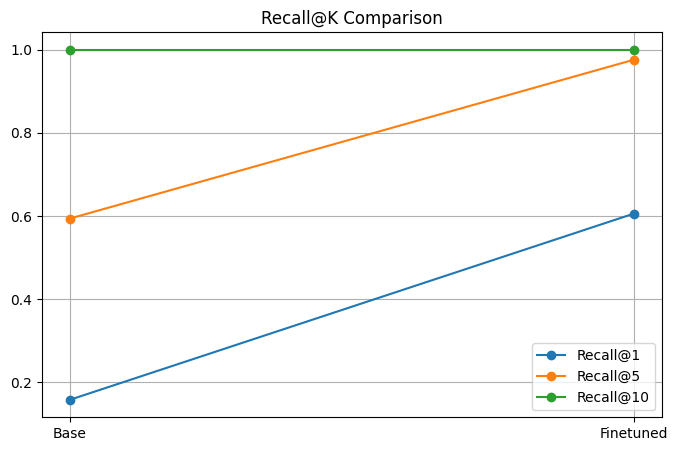

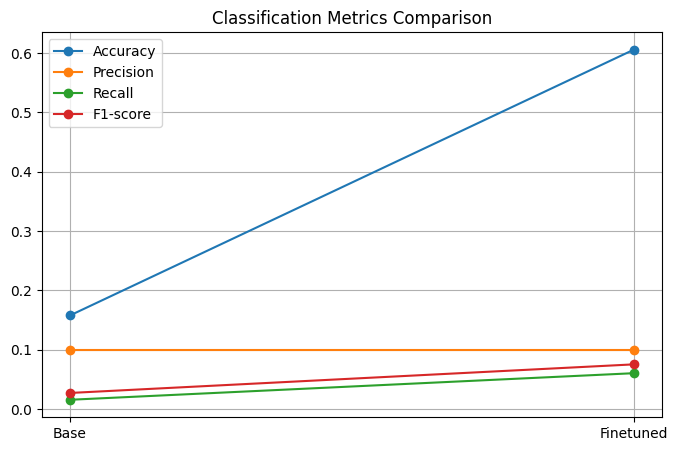

In [ ]:
metrics_recall, metrics_classif = evaluate_models(base_model, ft_model, processor)